# Sigmoid analysis
- Plotting activations

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob
import string

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import root_mean_squared_error
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [3]:
# load the datasets
payload_gauss = pickle.load(open(os.path.join(DATA_PATH, "trident_gauss_noise_2026-08-21.pkl"), "rb"))
payload_logistic = pickle.load(open(os.path.join(DATA_PATH, "trident_logisitc_noise_2026-08-21.pkl"), "rb"))

gauss_df = pd.DataFrame(payload_gauss["data"])
log_df = pd.DataFrame(payload_logistic["data"])

print(gauss_df.head())
print(f"Columns gauss: {gauss_df.columns}")
print(log_df.head())

     input  exp_state_gauss  exact_grad_gauss  exp_grad_gauss  \
0 -5.00000             -1.0               0.0             0.0   
1 -4.98999             -1.0               0.0             0.0   
2 -4.97998             -1.0               0.0             0.0   
3 -4.96997             -1.0               0.0             0.0   
4 -4.95996             -1.0               0.0             0.0   

   computed_exp_state  computed_grad   nu    std  
0                -1.0            0.0  2.0  0.001  
1                -1.0            0.0  2.0  0.001  
2                -1.0            0.0  2.0  0.001  
3                -1.0            0.0  2.0  0.001  
4                -1.0            0.0  2.0  0.001  
Columns gauss: Index(['input', 'exp_state_gauss', 'exact_grad_gauss', 'exp_grad_gauss',
       'computed_exp_state', 'computed_grad', 'nu', 'std'],
      dtype='str')
     input  exp_state_logistic  exact_grad_logistic  computed_exp_state  \
0 -5.00000                -1.0                  0.0          

In [4]:
# computing rmse: logistic activation
gauss_df["state_se"] = (gauss_df["exp_state_gauss"] - gauss_df["computed_exp_state"])**2

# scaling exact grad to mode match
gauss_df["exact_mm_grad_gauss"] = gauss_df["exact_grad_gauss"]*(jnp.sqrt(2*jnp.pi)*gauss_df["std"])/4

gauss_df['grad_se'] = (gauss_df['computed_grad'] - gauss_df['exact_mm_grad_gauss'])**2

gauss_df["act"] = 2*jnp.heaviside(gauss_df["input"].to_numpy(), 0) - 1



log_df["state_se"] = (log_df["exp_state_logistic"]-log_df["computed_exp_state"])**2
log_df["grad_se"] = (log_df["exact_grad_logistic"]-log_df["computed_grad"])**2
log_df["act"] = 2*jnp.heaviside(gauss_df["input"].to_numpy(), 0) - 1

# cleaning up the std columns
gauss_df["std"] = round(gauss_df["std"], 3)
log_df["std"] = round(log_df["std"], 3)

# gauss_df["nu"]


<Axes: xlabel='nu', ylabel='computed_exp_state_std'>

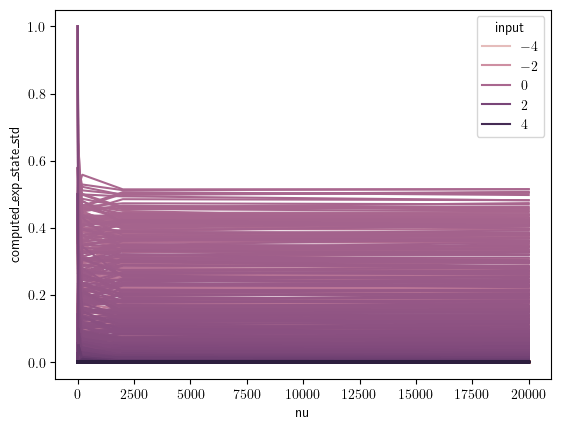

In [29]:
# making a new dataframe: input, nu, computed_exp_state_std, computed_grad_std
gauss_std_df = (
    gauss_df.groupby(["input", "nu"])[["computed_exp_state", "computed_grad"]]
    .std()
    .reset_index()
    .rename(columns={
        "computed_exp_state": "computed_exp_state_std",
        "computed_grad": "computed_grad_std",
    })
)

sns.lineplot(data=gauss_std_df, x="nu", y="computed_exp_state_std", hue="input")

/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_98415/3397074757.py:37: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(data=l_df, x="input", y="computed_exp_state", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax1, hue="nu")
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_98415/3397074757.py:44: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=log_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax2, hue="std", err_style="bars", err_kws={"capsize": 3})
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_98415/3397074757.py:52: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(data=g_df, x="input", y="computed_exp_state", lw=2.0, palette=cb_pal, alpha=0.6, ax=ax3, hue="nu")
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_98415/3397074757.py:58: UserWarning:

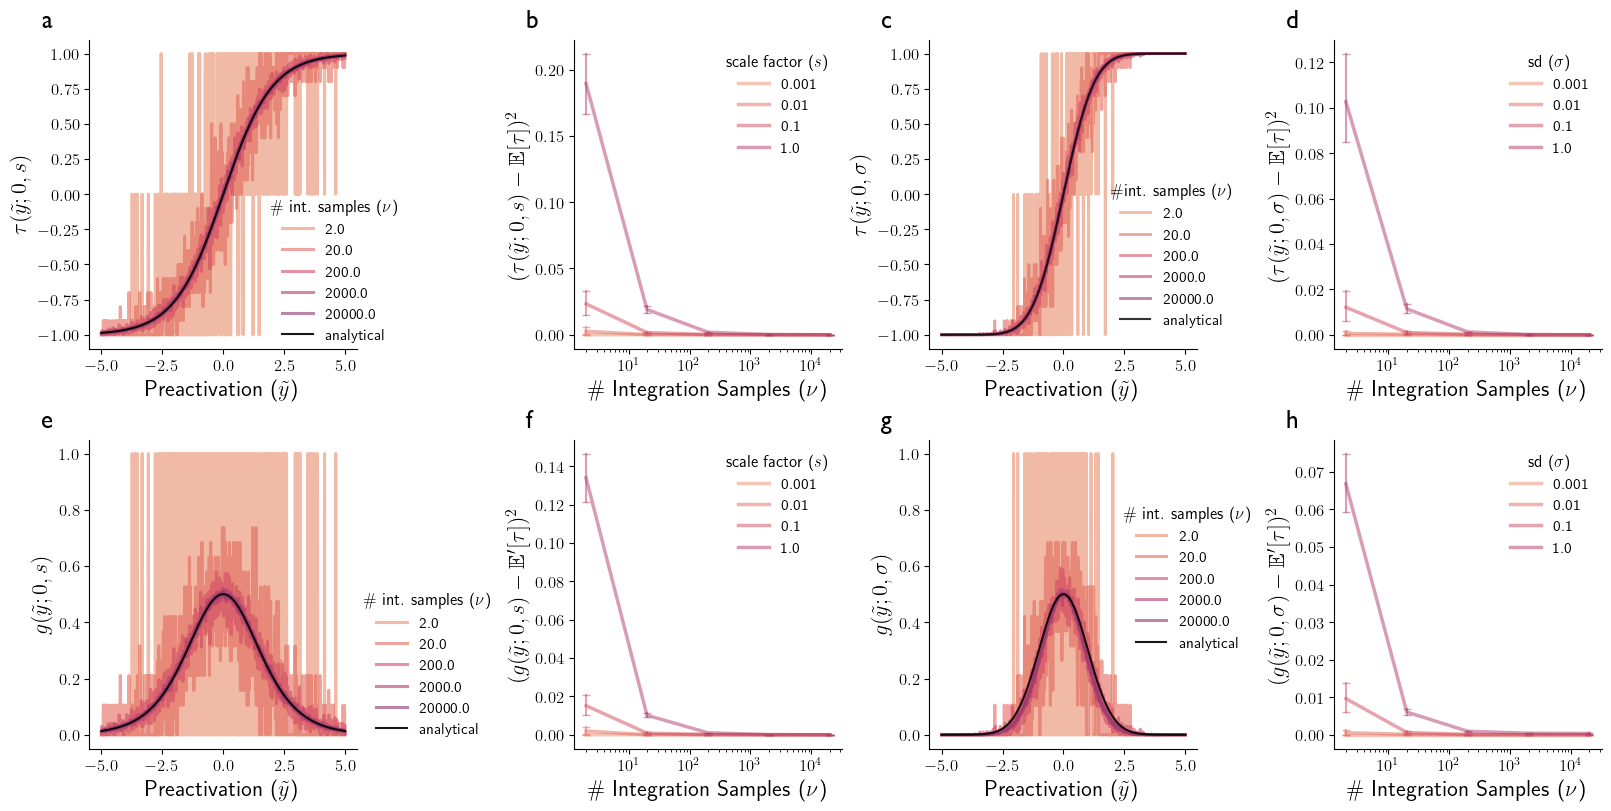

In [9]:
today = date.today().isoformat()

cb_pal = sns.color_palette("flare") # use this to toggle color palettes
inset_pal = sns.color_palette("crest")
# flare_pal = sns.color_palette("flare")

# filter across noise levels
std_sel = 1.0
sf_gauss = jnp.sqrt(2*jnp.pi)*std_sel/4
g_df = gauss_df.loc[gauss_df["std"] == std_sel]
l_df = log_df.loc[log_df["std"] == std_sel]

ex_log_df = l_df.loc[l_df["nu"] == 2.0] # df to store exact exp and grads for nu = 2 (nu value doesn't affect this)
ex_gauss_df = g_df.loc[g_df["nu"] == 2.0] # df to store exact exp and grads for nu = 2 (nu value doesn't affect this)

# fig = plt.figure(figsize=(15, 15), dpi=110)
# gs = GridSpec(2, 4, width_ratios=(1, 1), height_ratios=(1, 1, 1, 1), hspace=0.1, wspace=0.3)

# ax1 = fig.add_subplot(gs[0]) # logistic activation
# ax2 = fig.add_subplot(gs[1]) # logistic activation error
# ax3 = fig.add_gridspec(gs[2]) # gaussian activation
# ax4 = fig.add_gridspec(gs[4]) # gaussian activation error

fig, ax = plt.subplots(2, 4, figsize=(16, 8), layout="constrained")

ax1 = ax[0,0] # logistic activation
ax2 = ax[0,1] # logistic activation error
ax3 = ax[0,2] # gaussian activation
ax4 = ax[0,3] # gaussian activation error

ax5 = ax[1,0] # logistic grad
ax6 = ax[1,1] # logistic grad error
ax7 = ax[1,2] # gaussian grad
ax8 = ax[1,3] # gaussian grad error

# logistic activation plots
sns.lineplot(data=l_df, x="input", y="computed_exp_state", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax1, hue="nu")
sns.lineplot(data=ex_log_df, x="input", y="exp_state_logistic", lw=1.5, color="k", alpha=0.9, ax=ax1, label="analytical")
ax1.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax1.set_ylabel(r"$\tau(\tilde{y}; 0, s)$", fontsize=16)
# ax1.legend(frameon=False, title=r"$\nu$", title_fontsize=12, loc=(0.65, 0.02))
ax1.legend(frameon=False, title=r"\# int. samples ($\nu$)", title_fontsize=12, loc=(0.65, 0.0), fontsize=11)

sns.lineplot(data=log_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax2, hue="std", err_style="bars", err_kws={"capsize": 3})
ax2.set_xscale("log", base=10)
ax2.set_xlabel(r"\# Integration Samples ($\nu$)", fontsize=16)
ax2.set_ylabel(r"$(\tau(\tilde{y}; 0, s) - \mathbb{E}[\tau])^2$", fontsize=16)
ax2.legend(frameon=False, title=r"scale factor ($s$)", title_fontsize=12, fontsize=11)
# ax2.set_yscale("log", base=10)

# gaussian activation plots
sns.lineplot(data=g_df, x="input", y="computed_exp_state", lw=2.0, palette=cb_pal, alpha=0.6, ax=ax3, hue="nu")
sns.lineplot(data=ex_gauss_df, x="input", y="exp_state_gauss", lw=1.5, color="k", alpha=0.8, ax=ax3, label="analytical")
ax3.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax3.set_ylabel(r"$\tau(\tilde{y}; 0, \sigma)$", fontsize=16)
ax3.legend(frameon=False, title=r"\#int. samples ($\nu$)", title_fontsize=12, loc=(0.65, 0.05), fontsize=11)

sns.lineplot(data=gauss_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax4, hue="std", err_style="bars", err_kws={"capsize": 3})
ax4.set_xscale("log", base=10)
ax4.set_xlabel(r"\# Integration Samples ($\nu$)", fontsize=16)
ax4.set_ylabel(r"$(\tau(\tilde{y}; 0, \sigma) - \mathbb{E}[\tau])^2$", fontsize=16)
ax4.legend(frameon=False, title=r"sd ($\sigma$)", title_fontsize=12, fontsize=11)


# logistic gradient plots
sns.lineplot(data=l_df, x="input", y="computed_grad", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax5, hue="nu")
sns.lineplot(data=ex_log_df, x="input", y="exact_grad_logistic", lw=1.5, color="k", alpha=0.9, ax=ax5, label="analytical")
ax5.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax5.set_ylabel(r"$g(\tilde{y}; 0, s)$", fontsize=16)
ax5.legend(frameon=False, title=r"\# int. samples ($\nu$)", title_fontsize=12, loc=(1., 0.02), fontsize=11)

sns.lineplot(data=log_df, x="nu", y="grad_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax6, hue="std", err_style="bars", err_kws={"capsize": 3})
ax6.set_xscale("log", base=10)
ax6.set_xlabel(r"\# Integration Samples ($\nu$)", fontsize=16)
ax6.set_ylabel(r"$(g(\tilde{y}; 0, s) - \mathbb{E}^\prime[\tau])^2$", fontsize=16)
ax6.legend(frameon=False, title=r"scale factor ($s$)", title_fontsize=12, fontsize=11)


# gaussian gradient plots
sns.lineplot(data=g_df, x="input", y="computed_grad", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax7, hue="nu")
sns.lineplot(data=ex_gauss_df, x="input", y="exact_mm_grad_gauss", lw=1.5, color="k", alpha=0.9, ax=ax7, label="analytical")
ax7.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax7.set_ylabel(r"$g(\tilde{y}; 0, \sigma)$", fontsize=16)
ax7.legend(frameon=False, title=r"\# int. samples ($\nu$)", title_fontsize=12, loc=(0.7, 0.3), fontsize=11)

sns.lineplot(data=gauss_df, x="nu", y="grad_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax8, hue="std", err_style="bars", err_kws={"capsize": 3})
ax8.set_xscale("log", base=10)
ax8.set_xlabel(r"\# Integration Samples ($\nu$)", fontsize=16)
ax8.set_ylabel(r"$(g(\tilde{y}; 0, \sigma) - \mathbb{E}^\prime[\tau])^2$", fontsize=16)
ax8.legend(frameon=False, title=r"sd ($\sigma$)", title_fontsize=12, fontsize=11)

for axs in ax.ravel():
    axs.tick_params(axis="both", labelsize=12)

for n, axs in enumerate(ax.ravel()):
    axs.text(-0.18, 1.02, string.ascii_lowercase[n],
             transform=axs.transAxes,
             usetex=False,                      # bypass the LaTeX backend
             fontfamily="Gill Sans",            # or "Gill Sans MT" / "GillSans"
             fontweight="bold", fontsize=18,
             va="bottom", ha="left")


# plt.tight_layout(h_pad=0.5, w_pad=0.9)
# plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(FIGURES_PATH, f"noisy_activation_comparison_transparent_{today}.pdf"), bbox_inches="tight", transparent=True, dpi=300)

/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42526/3567639063.py:35: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(data=l_df, x="input", y="computed_exp_state", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax1, hue="nu")
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42526/3567639063.py:41: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=log_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax2, hue="std", err_style="bars", err_kws={"capsize": 3})
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42526/3567639063.py:50: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(data=log_df, x="std", y="state_se", lw=2.5, palette=inset_pal, alpha=0.5, ax=ax01_inset, hue="std", err_style="bars", err_kws={"capsize": 3})
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipy

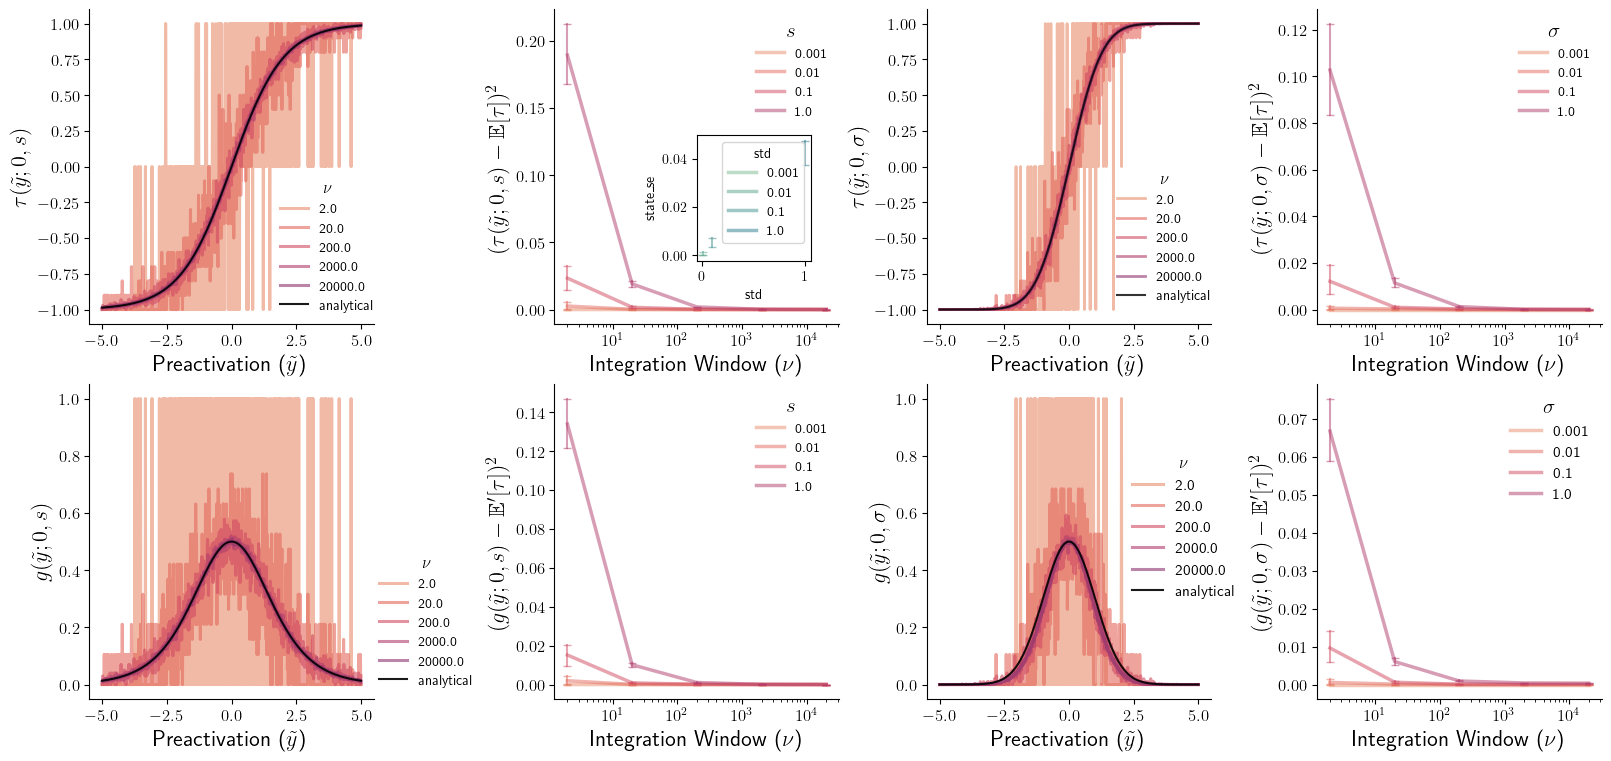

In [14]:
cb_pal = sns.color_palette("flare") # use this to toggle color palettes
inset_pal = sns.color_palette("crest")
# flare_pal = sns.color_palette("flare")

# filter across noise levels
std_sel = 1.0
sf_gauss = jnp.sqrt(2*jnp.pi)*std_sel/4
g_df = gauss_df.loc[gauss_df["std"] == std_sel]
l_df = log_df.loc[log_df["std"] == std_sel]

ex_log_df = l_df.loc[l_df["nu"] == 2.0] # df to store exact exp and grads for nu = 2 (nu value doesn't affect this)
ex_gauss_df = g_df.loc[g_df["nu"] == 2.0] # df to store exact exp and grads for nu = 2 (nu value doesn't affect this)

# fig = plt.figure(figsize=(15, 15), dpi=110)
# gs = GridSpec(2, 4, width_ratios=(1, 1), height_ratios=(1, 1, 1, 1), hspace=0.1, wspace=0.3)

# ax1 = fig.add_subplot(gs[0]) # logistic activation
# ax2 = fig.add_subplot(gs[1]) # logistic activation error
# ax3 = fig.add_gridspec(gs[2]) # gaussian activation
# ax4 = fig.add_gridspec(gs[4]) # gaussian activation error

fig, ax = plt.subplots(2, 4, figsize=(16, 7.5), layout="constrained")

ax1 = ax[0,0] # logistic activation
ax2 = ax[0,1] # logistic activation error
ax3 = ax[0,2] # gaussian activation
ax4 = ax[0,3] # gaussian activation error

ax5 = ax[1,0] # logistic grad
ax6 = ax[1,1] # logistic grad error
ax7 = ax[1,2] # gaussian grad
ax8 = ax[1,3] # gaussian grad error

# logistic activation plots
sns.lineplot(data=l_df, x="input", y="computed_exp_state", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax1, hue="nu")
sns.lineplot(data=ex_log_df, x="input", y="exp_state_logistic", lw=1.5, color="k", alpha=0.9, ax=ax1, label="analytical")
ax1.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax1.set_ylabel(r"$\tau(\tilde{y}; 0, s)$", fontsize=16)
ax1.legend(frameon=False, title=r"$\nu$", title_fontsize=12, loc=(0.65, 0.02))

sns.lineplot(data=log_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax2, hue="std", err_style="bars", err_kws={"capsize": 3})
ax2.set_xscale("log", base=10)
ax2.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax2.set_ylabel(r"$(\tau(\tilde{y}; 0, s) - \mathbb{E}[\tau])^2$", fontsize=16)
ax2.legend(frameon=False, title=r"$s$", title_fontsize=15)
# ax2.set_yscale("log", base=10)

## inset for ax[0, 1]
ax01_inset = ax[0, 1].inset_axes([0.5, 0.2, 0.4, 0.4])
sns.lineplot(data=log_df, x="std", y="state_se", lw=2.5, palette=inset_pal, alpha=0.5, ax=ax01_inset, hue="std", err_style="bars", err_kws={"capsize": 3})

# gaussian activation plots
sns.lineplot(data=g_df, x="input", y="computed_exp_state", lw=2.0, palette=cb_pal, alpha=0.6, ax=ax3, hue="nu")
sns.lineplot(data=ex_gauss_df, x="input", y="exp_state_gauss", lw=1.5, color="k", alpha=0.8, ax=ax3, label="analytical")
ax3.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax3.set_ylabel(r"$\tau(\tilde{y}; 0, \sigma)$", fontsize=16)
ax3.legend(frameon=False, title=r"$\nu$", title_fontsize=12, loc=(0.65, 0.05))

sns.lineplot(data=gauss_df, x="nu", y="state_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax4, hue="std", err_style="bars", err_kws={"capsize": 3})
ax4.set_xscale("log", base=10)
ax4.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax4.set_ylabel(r"$(\tau(\tilde{y}; 0, \sigma) - \mathbb{E}[\tau])^2$", fontsize=16)
ax4.legend(frameon=False, title=r"$\sigma$", title_fontsize=15)


# logistic gradient plots
sns.lineplot(data=l_df, x="input", y="computed_grad", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax5, hue="nu")
sns.lineplot(data=ex_log_df, x="input", y="exact_grad_logistic", lw=1.5, color="k", alpha=0.9, ax=ax5, label="analytical")
ax5.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax5.set_ylabel(r"$g(\tilde{y}; 0, s)$", fontsize=16)
ax5.legend(frameon=False, title=r"$\nu$", title_fontsize=12, loc=(1., 0.02))

sns.lineplot(data=log_df, x="nu", y="grad_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax6, hue="std", err_style="bars", err_kws={"capsize": 3})
ax6.set_xscale("log", base=10)
ax6.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax6.set_ylabel(r"$(g(\tilde{y}; 0, s) - \mathbb{E}^\prime[\tau])^2$", fontsize=16)
ax6.legend(frameon=False, title=r"$s$", title_fontsize=15)


# gaussian gradient plots
sns.lineplot(data=g_df, x="input", y="computed_grad", lw=2.2, palette=cb_pal, alpha=0.6, ax=ax7, hue="nu")
sns.lineplot(data=ex_gauss_df, x="input", y="exact_mm_grad_gauss", lw=1.5, color="k", alpha=0.9, ax=ax7, label="analytical")
ax7.set_xlabel(r"Preactivation ($\tilde{y}$)", fontsize=16)
ax7.set_ylabel(r"$g(\tilde{y}; 0, \sigma)$", fontsize=16)
ax7.legend(frameon=False, title=r"$\nu$", title_fontsize=12, loc=(0.7, 0.3), fontsize=11)

sns.lineplot(data=gauss_df, x="nu", y="grad_se", lw=2.5, palette=cb_pal, alpha=0.5, ax=ax8, hue="std", err_style="bars", err_kws={"capsize": 3})
ax8.set_xscale("log", base=10)
ax8.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax8.set_ylabel(r"$(g(\tilde{y}; 0, \sigma) - \mathbb{E}^\prime[\tau])^2$", fontsize=16)
ax8.legend(frameon=False, title=r"$\sigma$", title_fontsize=15, fontsize=11)

for axs in ax.ravel():
    axs.tick_params(axis="both", labelsize=12)


# plt.tight_layout(h_pad=0.5, w_pad=0.9)
# plt.tight_layout()
sns.despine()

# plt.savefig(os.path.join(FIGURES_PATH, f"noisy_activation_comparison_transparent_{today}.pdf"), bbox_inches="tight", transparent=True, dpi=300)

In [189]:
key = jax.random.key(0)
key, subkey = jax.random.split(key)
x_test = jax.random.normal(key, (5, 3, 3))
n = jax.random.normal(key=subkey, shape=x_test.shape+(10,))
x_test = x_test[..., None] + n
print(x_test)

[[[[-1.4384415e+00 -1.0316663e+00  1.2095585e+00  6.5046406e-01
     2.4204022e-01 -1.7453754e-01 -1.4420533e-01  1.3011800e+00
    -3.0652165e-01  3.1342168e+00]
   [-1.0959096e+00  5.7674944e-02 -2.2074373e+00 -1.6550310e+00
    -1.2793356e+00 -4.6354651e-01 -2.0966368e+00 -9.7559285e-01
    -1.8623960e+00 -2.8651011e+00]
   [-1.8541665e+00 -1.0701774e+00  5.8215767e-01  6.4064622e-02
    -1.9069960e+00 -1.2914135e+00  5.9658170e-02  9.0643209e-01
    -1.1574821e+00 -6.9428378e-01]]

  [[-1.8197551e+00 -2.9389625e+00 -1.3828971e+00 -2.4893612e-01
    -2.4702454e+00 -1.8862444e+00 -3.5738046e+00 -2.8484612e+00
    -1.6412027e+00 -2.8863263e+00]
   [-2.8599625e+00 -2.5219553e+00 -1.1456821e+00 -1.5902032e+00
    -4.7817978e-01 -1.8123040e+00  1.0453994e+00 -3.1453216e-01
    -9.5035100e-01 -1.0415310e-01]
   [ 1.5047987e+00 -5.4330635e-01  1.2792267e+00 -7.8475404e-01
     7.7482891e-01 -1.0153625e+00  1.1462721e-01  1.0890148e+00
    -1.6003841e-01  1.5569844e+00]]

  [[ 4.1517583e-01